<a href="https://colab.research.google.com/github/Dev-Nada/Face-recognition/blob/main/Face_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries & Tools

In [173]:
# !pip install insightface

In [174]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import insightface
from insightface.app import FaceAnalysis
from insightface.utils import face_align
from sklearn.metrics.pairwise import cosine_similarity

#YuNet Face Detector

In [175]:
model_path ="face_detection_yunet_2023mar.onnx"

In [176]:
detect_face = cv2.FaceDetectorYN.create(
    model_path,
    "",
    (320, 320),
    score_threshold=0.7,
    nms_threshold=0.3,
    top_k=1000
)


#Try-1

In [177]:
img =cv2.imread("/content/9007268003091698.jpg")
print(img.shape)

(562, 495, 3)


(np.float64(-0.5), np.float64(494.5), np.float64(561.5), np.float64(-0.5))

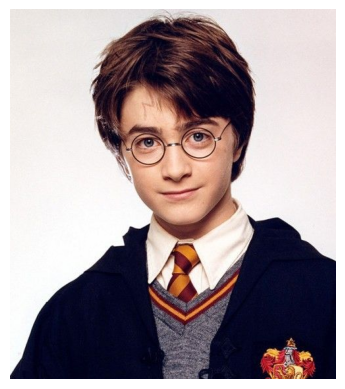

In [178]:
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")

#Detection

In [179]:
h,w=img.shape[:2]
detect_face.setInputSize((w,h))
_,faces=detect_face.detect(img)
print("faces:", 0 if faces is None else len(faces))

faces: 1


#Validation

In [180]:
if faces is None:
    raise ValueError("No face detected.")

if len(faces) > 1:
    raise ValueError("Multiple faces Please provide an image with one face")

print("one face detected.")

conf = float(faces[0][-1])
print("confidence:", conf)

if conf < 0.7:
    raise ValueError("Can not sure with detection")

one face detected.
confidence: 0.9386463761329651


#Bounding Box

In [181]:
x,y,w,h=faces[0][:4]
x=int(x)
y=int(y)
w=int(w)
h=int(h)
print(x,y,h,w)

170 111 216 169


#Try to catch the face

In [182]:
#Padding for more freedom
padding_x = 0.15
padding_y = 0.15

x1 = max(0, int(x - w * padding_x))
y1 = max(0, int(y - h * padding_y))

x2 = min(img.shape[1], int(x + w * (1 + padding_x)))
y2 = min(img.shape[0], int(y + h * (1 + padding_y)))

face_crop = img[y1:y2, x1:x2]

(np.float64(-0.5), np.float64(219.5), np.float64(280.5), np.float64(-0.5))

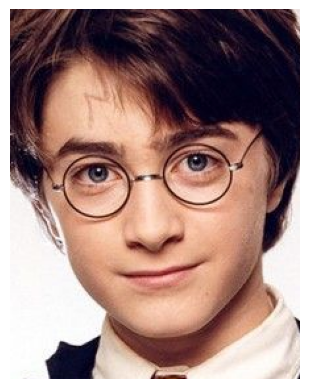

In [183]:
plt.imshow(cv2.cvtColor(face_crop,cv2.COLOR_BGR2RGB))
plt.axis("off")

#Function contain all steps

In [184]:
def detect_and_crop_face(image):

    h, w = image.shape[:2]
    detect_face.setInputSize((w, h))

    _, faces = detect_face.detect(image)

    if faces is None:
        raise ValueError("No face detected.")

    if len(faces) > 1:
        raise ValueError("Multiple faces Please provide an image with one face")

    confidence = float(faces[0][-1])

    if confidence < 0.7:
        raise ValueError("Can not sure with detection")

    x, y, face_w, face_h = faces[0][:4]

    x = int(x)
    y = int(y)
    face_w = int(face_w)
    face_h = int(face_h)

    padding_x = 0.15
    padding_y = 0.15

    x1 = max(0, int(x - face_w * padding_x))
    y1 = max(0, int(y - face_h * padding_y))

    x2 = min(w, int(x + face_w * (1 + padding_x)))
    y2 = min(h, int(y + face_h * (1 + padding_y)))

    face_crop = image[y1:y2, x1:x2]
    box = (x1, y1, x2, y2)

    return face_crop, box, confidence

Box: (144, 78, 364, 359)
Confidence: 0.9386463761329651
Crop shape: (281, 220, 3)


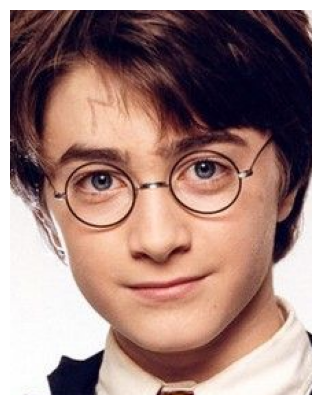

In [185]:
#Making sure of function result
face, box, confidence = detect_and_crop_face(img)

if face is not None:
    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
    plt.axis("off");
else:
    print("No face detected")

print("Box:", box)
print("Confidence:", confidence)
print("Crop shape:", face.shape)

#Face Recognition

In [186]:
app = FaceAnalysis(name="buffalo_l", providers=["CPUExecutionProvider"])
app.prepare(ctx_id=-1, det_size=(640, 640))

print('success')

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
success


#Get ArcFace Recognition Model

In [187]:
print(app.models.keys())

dict_keys(['landmark_3d_68', 'landmark_2d_106', 'detection', 'genderage', 'recognition'])


In [188]:
reco_model =app.models["recognition"]
print(type(reco_model))

<class 'insightface.model_zoo.arcface_onnx.ArcFaceONNX'>


#Extract Facial Landmarks

In [189]:
face_data = faces[0]

landmarks = face_data[4:14].reshape(5, 2)

print(landmarks)

[[207.1858  204.40219]
 [286.50433 194.42534]
 [250.09175 244.28369]
 [225.33347 279.85123]
 [289.41614 271.0539 ]]


#Align Face

In [190]:
aligned_face = face_align.norm_crop(
    img,
    landmarks
)

print(aligned_face.shape)

(112, 112, 3)


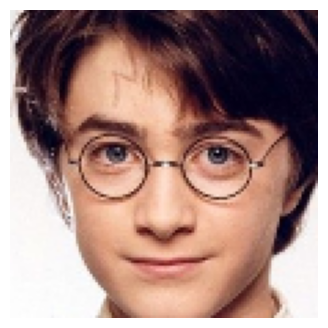

In [191]:
plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB))
plt.axis("off");

#Embedding

In [192]:
embedding = reco_model.get_feat(aligned_face)

print("Embedding Shape:", embedding.shape)

Embedding Shape: (1, 512)


#Normalize

In [193]:
embedding = embedding / np.linalg.norm(embedding)

print(embedding.shape)
print(np.linalg.norm(embedding))

(1, 512)
1.0


#Img test 2

In [194]:
#Same person in img 1 (Try 1)
img2 = cv2.imread("/content/598345500533707915.jpg")

face2, box2, confidence2 = detect_and_crop_face(img2)

print("Confidence:", confidence2)
print("Crop shape:", face2.shape)

Confidence: 0.9337636828422546
Crop shape: (260, 212, 3)


(np.float64(-0.5), np.float64(735.5), np.float64(882.5), np.float64(-0.5))

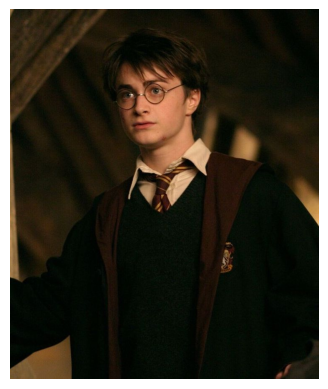

In [195]:
plt.imshow(cv2.cvtColor(img2,cv2.COLOR_BGR2RGB))
plt.axis("off")

In [196]:
face_data2 = detect_face.detect(img2)[1][0]

landmarks2 = face_data2[4:14].reshape(5, 2)

print(landmarks2)

[[282.37    204.63434]
 [343.3635  201.46973]
 [297.46667 243.36948]
 [293.6941  276.6505 ]
 [343.20306 273.00333]]


In [197]:
aligned_face2 = face_align.norm_crop(
    img2,
    landmarks2
)

print(aligned_face2.shape)

(112, 112, 3)


In [198]:
embedding2 = reco_model.get_feat(aligned_face2)
print("Embedding Shape:", embedding2.shape)

Embedding Shape: (1, 512)


In [199]:
embedding2 = embedding2 / np.linalg.norm(embedding2)

In [200]:
#Compare Image 1 vs Image 2 (Same person)
similarity = cosine_similarity(embedding, embedding2)

print(similarity)

[[0.61174124]]


#Try-3 ( differ person )

In [201]:
img3 = cv2.imread("/content/123145371041737442.jpg")

face3, box3, confidence3 = detect_and_crop_face(img3)

print("Confidence:", confidence3)
print("Crop shape:", face3.shape)

Confidence: 0.8748050928115845
Crop shape: (764, 587, 3)


In [202]:
face_data3 = detect_face.detect(img3)[1][0]

landmarks3 = face_data3[4:14].reshape(5, 2)

In [203]:
aligned_face3 = face_align.norm_crop(
    img3,
    landmarks3
)

print(aligned_face3.shape)

(112, 112, 3)


In [204]:
embedding3 = reco_model.get_feat(aligned_face3)

print("Embedding Shape:", embedding3.shape)

Embedding Shape: (1, 512)


In [205]:
embedding3 = embedding3 / np.linalg.norm(embedding3)

In [206]:
#Compare Image 1 vs Image 3 (NOt the Same person)
similarity = cosine_similarity(embedding, embedding3)

print(similarity)

[[0.06147074]]


#Mean embedding function

In [207]:
def get_face_embedding(image):

    h, w = image.shape[:2]
    detect_face.setInputSize((w, h))
    _, faces = detect_face.detect(image)

    if faces is None:
        raise ValueError("No face detected.")

    if len(faces) > 1:
        raise ValueError(
            "Multiple faces provide an image with exactly one face."
        )

    conf = float(faces[0][-1])

    if conf < 0.7:
        raise ValueError("Face detection confidence is too low")

    face_data = faces[0]
    landmarks = face_data[4:14].reshape(5, 2)


    aligned_face = face_align.norm_crop(image,landmarks)

    embedding = reco_model.get_feat(aligned_face)

    embedding = embedding / np.linalg.norm(embedding)

    return embedding

#Function to check similarity

In [208]:
def compare_faces(embedding1, embedding2):

    similarity = cosine_similarity(
        embedding1,
        embedding2
    )[0][0]

    is_match = similarity >= 0.5

    return similarity, is_match